# Trabalho de Machine Learning

Aprendizado não supervisionado

Equipe:

- José Vinícius Evangelista de Souza - 537071
    - Feature Engineering
    - Feature Selection
    - KMeans
- Francisco Paulino Arruda Filho - 538451
    - DBSCAN
    - plotagem
- Gabriel Al-Samir Guimarães Sales - 536039
    - Clusterização Hierárquica
    - plotagem

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from typing import Generator, Sequence
import seaborn as sns
from itertools import product

from sklearn.metrics import (
    calinski_harabasz_score,
    silhouette_score,
    davies_bouldin_score,
)

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN

In [2]:
DATA_PATH = Path("./data")
SPOTIFY_DATA_PATH = DATA_PATH / "spotify_songs.parquet"

In [3]:
RANDOM_STATE = 42
N_CLUSTERS = 6

In [4]:
spotify_df = pd.read_parquet(SPOTIFY_DATA_PATH)
spotify_df

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432


In [5]:
(
    len(spotify_df.playlist_name.unique()),
    len(spotify_df.playlist_id.unique()),
    len(spotify_df.track_id.unique()),
)

(449, 471, 28356)

In [6]:
categorical_cols = [
    "playlist_genre",
    "playlist_subgenre",
]

sdf_categorized = pd.get_dummies(
    spotify_df, columns=categorical_cols, drop_first=True, dtype="int64"
)
sdf_categorized

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,danceability,...,playlist_subgenre_new jack swing,playlist_subgenre_permanent wave,playlist_subgenre_pop edm,playlist_subgenre_post-teen pop,playlist_subgenre_progressive electro house,playlist_subgenre_reggaeton,playlist_subgenre_southern hip hop,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_urban contemporary
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,0.748,...,0,0,0,0,0,0,0,0,0,0
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,0.726,...,0,0,0,0,0,0,0,0,0,0
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,0.675,...,0,0,0,0,0,0,0,0,0,0
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,0.718,...,0,0,0,0,0,0,0,0,0,0
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,0.650,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,0.428,...,0,0,0,0,1,0,0,0,0,0
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,0.522,...,0,0,0,0,1,0,0,0,0,0
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,0.529,...,0,0,0,0,1,0,0,0,0,0
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,0.626,...,0,0,0,0,1,0,0,0,0,0


In [7]:
drop_cols = [
    "track_id",
    "playlist_id",
    "playlist_name",
    "track_name",
    "track_album_name",
    "playlist_name",
    "track_artist",
    "track_album_id",
    "track_album_release_date",
    "key",  # Não sei o que é, PRECISA DE EXPLICAÇÃO
    "mode",  # Não sei o que é, PRECISA DE EXPLICAÇÃO
]

X = sdf_categorized.drop(columns=drop_cols)
X

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,...,playlist_subgenre_new jack swing,playlist_subgenre_permanent wave,playlist_subgenre_pop edm,playlist_subgenre_post-teen pop,playlist_subgenre_progressive electro house,playlist_subgenre_reggaeton,playlist_subgenre_southern hip hop,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_urban contemporary
0,66,0.748,0.916,-2.634,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,...,0,0,0,0,0,0,0,0,0,0
1,67,0.726,0.815,-4.969,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,...,0,0,0,0,0,0,0,0,0,0
2,70,0.675,0.931,-3.432,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,...,0,0,0,0,0,0,0,0,0,0
3,60,0.718,0.930,-3.778,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,...,0,0,0,0,0,0,0,0,0,0
4,69,0.650,0.833,-4.672,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,42,0.428,0.922,-1.814,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,...,0,0,0,0,1,0,0,0,0,0
32829,20,0.522,0.786,-4.462,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,...,0,0,0,0,1,0,0,0,0,0
32830,14,0.529,0.821,-4.899,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,...,0,0,0,0,1,0,0,0,0,0
32831,15,0.626,0.888,-3.361,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,...,0,0,0,0,1,0,0,0,0,0


In [8]:
def scale_and_concat_categorical(
    X: pd.DataFrame, categorical_cols: list[str]
) -> tuple[np.ndarray, list[str]]:
    """
    Scales non-categorical features and concatenates them with categorical features.

    Parameters:
        X: pd.DataFrame
            DataFrame with features.
        categorical_cols: list of str
            List of categorical column name patterns (prefixes).

    Returns:
        np.ndarray: Combined array of scaled non-categorical and categorical features.
        list: List of extracted categorical feature names.
    """
    extracted_categorical_features = [
        c for c in X.columns if any(cc in c for cc in categorical_cols)
    ]
    X_categorical = X[extracted_categorical_features]
    X_non_categorical = X.drop(columns=extracted_categorical_features)

    scaler = StandardScaler()
    X_scaled_non_cat = scaler.fit_transform(X_non_categorical)

    X_scaled = np.hstack([X_scaled_non_cat, X_categorical.values])
    return X_scaled, extracted_categorical_features

In [9]:
def chunkify[T](
    iterable: Sequence[T], size: int = 2
) -> Generator[Sequence[T], None, None]:
    """
    Yield successive n-sized chunks from iterable.
    """
    for i in range(0, len(iterable), size):
        yield iterable[i : i + size]

In [10]:
X_scaled, extracted_categorical_features = scale_and_concat_categorical(
    X, categorical_cols
)
X_scaled

array([[ 0.94153086,  0.64204909,  1.20161406, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.98155697,  0.49041187,  0.64331701, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.10163529,  0.13888922,  1.28452946, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.13982668, -0.86743053,  0.67648317, ...,  0.        ,
         0.        ,  0.        ],
       [-1.09980057, -0.19884823,  1.04683864, ...,  0.        ,
         0.        ,  0.        ],
       [-0.61948729, -0.35737806,  1.02472786, ...,  0.        ,
         0.        ,  0.        ]], shape=(32833, 39))

In [11]:
extracted_categorical_features

['playlist_genre_latin',
 'playlist_genre_pop',
 'playlist_genre_r&b',
 'playlist_genre_rap',
 'playlist_genre_rock',
 'playlist_subgenre_big room',
 'playlist_subgenre_classic rock',
 'playlist_subgenre_dance pop',
 'playlist_subgenre_electro house',
 'playlist_subgenre_electropop',
 'playlist_subgenre_gangster rap',
 'playlist_subgenre_hard rock',
 'playlist_subgenre_hip hop',
 'playlist_subgenre_hip pop',
 'playlist_subgenre_indie poptimism',
 'playlist_subgenre_latin hip hop',
 'playlist_subgenre_latin pop',
 'playlist_subgenre_neo soul',
 'playlist_subgenre_new jack swing',
 'playlist_subgenre_permanent wave',
 'playlist_subgenre_pop edm',
 'playlist_subgenre_post-teen pop',
 'playlist_subgenre_progressive electro house',
 'playlist_subgenre_reggaeton',
 'playlist_subgenre_southern hip hop',
 'playlist_subgenre_trap',
 'playlist_subgenre_tropical',
 'playlist_subgenre_urban contemporary']

In [12]:
def compute_pca_2d(X, random_state=42):
    """
    Reduce data to 2 dimensions with PCA.
    """
    return PCA(n_components=2, random_state=random_state).fit_transform(X)

In [13]:
def compute_tsne_2d(
    X, perplexity=30, max_iter=1000, learning_rate="auto", random_state=42
):
    """
    Reduce data to 2 dimensions with t‑SNE.
    """
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        max_iter=max_iter,
        learning_rate=learning_rate,
        random_state=random_state,
        init="pca",
    )
    return tsne.fit_transform(X)

In [14]:
def plot_embedding_2d(embedding: np.ndarray, labels: np.ndarray, title="2‑D Cluster Visualization"):
    """
    Scatter‑plot a 2‑D embedding coloured by cluster labels.
    """
    plt.figure(figsize=(10, 4))
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="viridis",
        s=15,
        alpha=0.5,
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.colorbar(label="Cluster")
    plt.tight_layout()
    plt.show()

## K-means

### Looking for better k value using k_elbow and silhouette visualizer

In [15]:
def run_kmeans(
    X: np.ndarray, models: list[KMeans]
) -> np.ndarray[tuple[int, int], np.dtype[np.float64]]:
    """
    Fit KMeans models and return list of (model, labels) tuples.
    """

    results = []
    for model in models:
        labels = model.fit_predict(X)
        inertia = model.inertia_
        ss = silhouette_score(X, labels)
        results.append((inertia, ss))

    return np.array(results, dtype=np.float64)

def compute_kmeans_metrics(X, k=(4, 12), random_state=None):
    min_k, max_k = k
    if min_k < 2 or max_k < min_k:
        raise ValueError("k must be a tuple with k[0] >= 2 and k[1] >= k[0]")

    inertia = []
    silhouette_scores = []

    for n in range(min_k, max_k + 1):
        model = KMeans(n_clusters=n, random_state=random_state)
        labels = model.fit_predict(X)
        inertia.append(model.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))

    return np.array(inertia), np.array(silhouette_scores), min_k, max_k


In [16]:
def plot_elbow_curve(inertia, min_k, max_k, show=True):
    diffs = np.diff(inertia)
    elbow = np.argmin(np.abs(diffs - np.mean(diffs))) + min_k + 1

    plt.figure(figsize=(10, 4))
    plt.plot(range(min_k, max_k + 1), inertia, marker="o", label="Inertia")
    plt.axvline(elbow, color="red", linestyle="--", label=f"Elbow: {elbow}")
    plt.title("KMeans Inertia vs Number of Clusters")
    plt.xlabel("Number of clusters")
    plt.ylabel("Inertia")
    plt.xticks(range(min_k, max_k + 1))
    plt.grid()
    plt.legend()

    if show:
        plt.show()

    return elbow


In [17]:
def plot_silhouette_scores(silhouette_scores, min_k, max_k, show=True):
    best_k = np.argmax(silhouette_scores) + min_k

    plt.figure(figsize=(10, 4))
    plt.plot(
        range(min_k, max_k + 1), silhouette_scores, marker="o", label="Silhouette Score"
    )
    plt.axvline(best_k, color="red", linestyle="--", label=f"Best k: {best_k}")
    plt.title("KMeans Silhouette Score vs Number of Clusters")
    plt.xlabel("Number of clusters")
    plt.ylabel("Silhouette Score")
    plt.xticks(range(min_k, max_k + 1))
    plt.grid()
    plt.legend()

    if show:
        plt.show()

    return best_k


In [18]:
inertia, silhouette_scores, min_k, max_k = compute_kmeans_metrics(X_scaled, k=(4, 12), random_state=RANDOM_STATE)

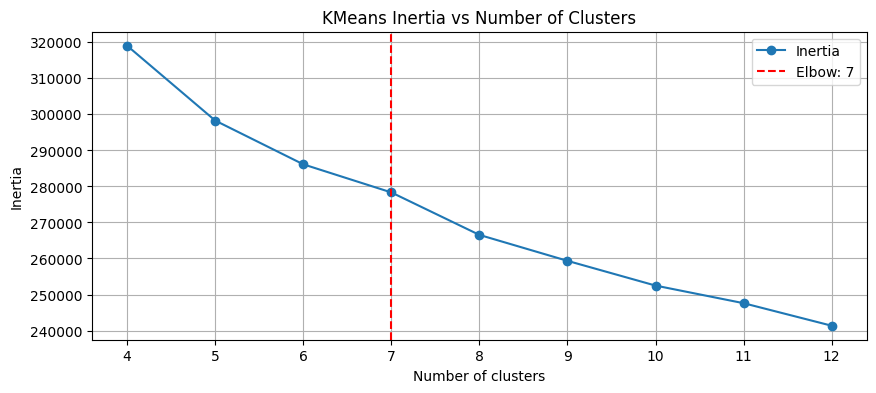

In [19]:

elbow_k = plot_elbow_curve(inertia, min_k, max_k)

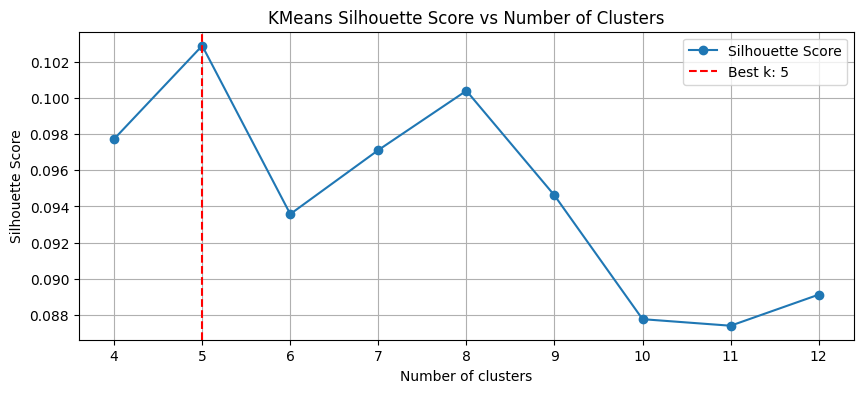

In [20]:
silhouette_k = plot_silhouette_scores(silhouette_scores, min_k, max_k)

### K-Means Clustering Evaluation with Internal Validation Metrics
The elbow graph shows the end of a big fall after k = 7. The silhouette graph, shows an apparent growth for the value ​​k = 5. For this reason we will try k = 5 for the other analyses.

In [21]:
N_CLUSTERS = 5

In [22]:
def get_kmeans_labels(X: np.ndarray, n_clusters: int, random_state: int = RANDOM_STATE) -> np.ndarray:
    """
    Fit KMeans and return labels.
    """
    model = KMeans(n_clusters=n_clusters, random_state=random_state)
    labels = model.fit_predict(X)
    return labels

In [23]:
labels = get_kmeans_labels(X_scaled, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)

In [24]:
def evaluate_kmeans_metrics(X, labels: np.ndarray,k_value=N_CLUSTERS):
    """
    Compute Silhouette, Davies-Bouldin, and Calinski-Harabasz scores for K-Means
    for a fixed k value.

    Returns a DataFrame with metrics as rows and k_value as the single column.
    """
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    data = {"Silhouette": sil, "Davies-Bouldin": db, "Calinski-Harabasz": ch}

    df = pd.DataFrame(data, index=[k_value]).T
    df.columns = [f"k={k_value}"]
    return df

In [25]:
metrics_df = evaluate_kmeans_metrics(
    X_scaled, k_value=N_CLUSTERS, labels=labels
)
metrics_df

,k=5
Silhouette,0.102885
Davies-Bouldin,2.205465
Calinski-Harabasz,3183.027402


### 2‑D Visualization of Clustering Results with PCA & t‑SNE

In [26]:
pca_coords = compute_pca_2d(X_scaled, random_state=RANDOM_STATE)

In [27]:
tsne_coords = compute_tsne_2d(X_scaled, perplexity=40, random_state=RANDOM_STATE)

Ploting PCA:

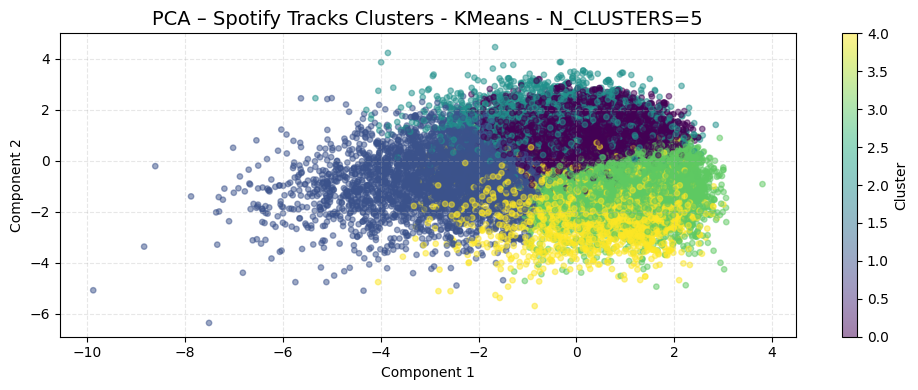

In [28]:
plot_embedding_2d(
    pca_coords,
    labels,
    title="PCA – Spotify Tracks Clusters - KMeans - N_CLUSTERS=5",
)

Ploting TSNE:

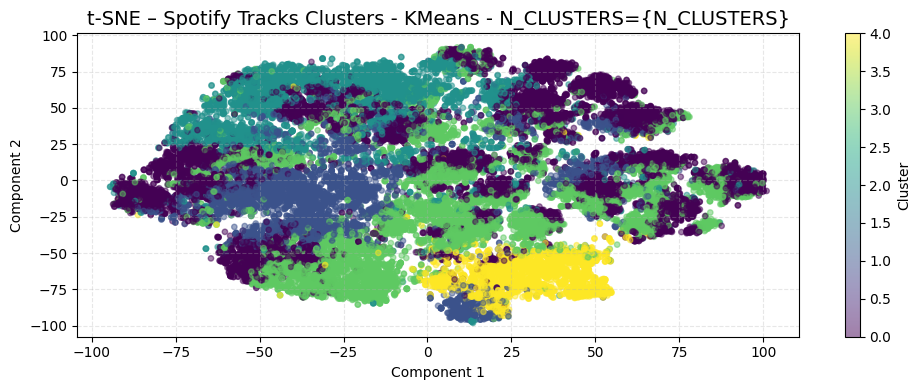

In [29]:
plot_embedding_2d(
    tsne_coords,
    labels,
    title="t‑SNE – Spotify Tracks Clusters - KMeans - N_CLUSTERS={N_CLUSTERS}",
)

## DBSCAN

In [30]:
dbscan = DBSCAN(eps=0.8, min_samples=3).fit(X_scaled)

### Test different hyperparameter values

### Filter labels == -1

In [31]:
def evaluate_dbscan(X, model):
    labels = model.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    # Filtrar ruído
    mask = labels != -1
    X_filtered = X[mask]
    labels_filtered = labels[mask]

    if n_clusters < 2 or len(X_filtered) < 2:
        return {
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette_score": None,
            "calinski_harabasz_score": None,
            "davies_bouldin_score": None,
        }

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette_score": silhouette_score(X_filtered, labels_filtered),
        "calinski_harabasz_score": calinski_harabasz_score(X_filtered, labels_filtered),
        "davies_bouldin_score": davies_bouldin_score(X_filtered, labels_filtered),
    }


### Test different hyperparameter values

In [32]:
eps_values = [0.3, 0.5, 0.8, 1.0, 1.5]
min_samples_values = [2, 3, 4, 5, 6]

results = []
for eps, min_samples in product(eps_values, min_samples_values):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    metrics = evaluate_dbscan(X_scaled, dbscan)
    metrics.update({"eps": eps, "min_samples": min_samples})
    results.append(metrics)

df_results = pd.DataFrame(results)

In [33]:
df_results

,n_clusters,n_noise,silhouette_score,calinski_harabasz_score,davies_bouldin_score,eps,min_samples
0,212,32406,0.904765,1246.813731,0.106197,0.3,2
1,3,32824,0.946532,2064.801739,0.065472,0.3,3
2,0,32833,NaN,NaN,NaN,0.3,4
3,0,32833,NaN,NaN,NaN,0.3,5
4,0,32833,NaN,NaN,NaN,0.3,6
5,390,32036,0.821343,397.286550,0.205294,0.5,2
6,16,32784,0.839342,322.033343,0.198350,0.5,3
7,0,32833,NaN,NaN,NaN,0.5,4
8,0,32833,NaN,NaN,NaN,0.5,5
9,0,32833,NaN,NaN,NaN,0.5,6


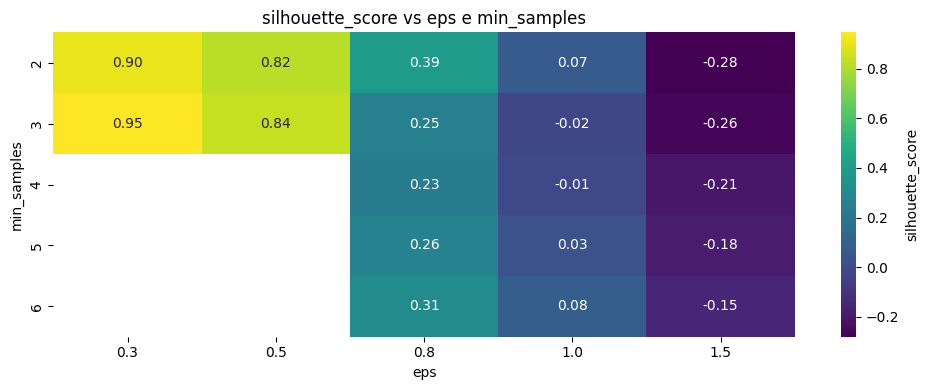

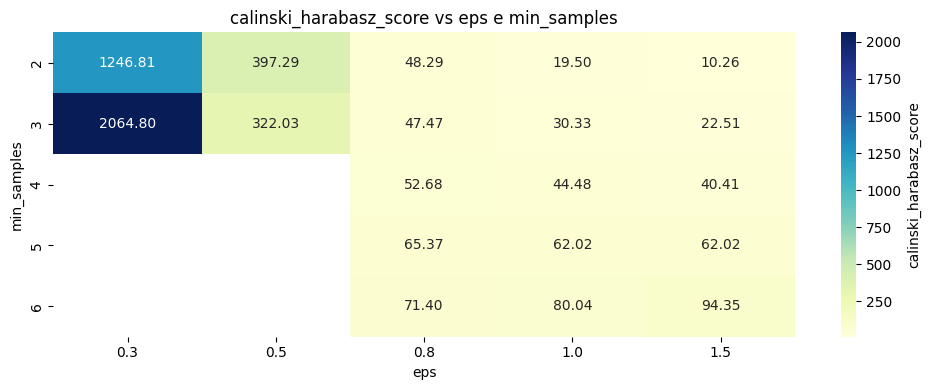

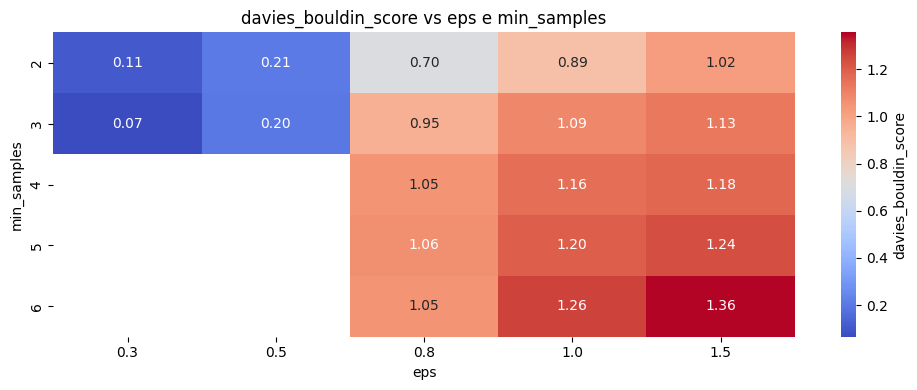

In [34]:
df_plot = df_results.dropna(
    subset=["silhouette_score", "calinski_harabasz_score", "davies_bouldin_score"]
)

def plot_heatmap(metric_name, cmap="viridis"):
    pivot = df_plot.pivot(index="min_samples", columns="eps", values=metric_name)
    plt.figure(figsize=(10, 4))
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap=cmap, cbar_kws={"label": metric_name}
    )
    plt.title(f"{metric_name} vs eps e min_samples")
    plt.xlabel("eps")
    plt.ylabel("min_samples")
    plt.tight_layout()
    plt.show()


plot_heatmap("silhouette_score")
plot_heatmap("calinski_harabasz_score", cmap="YlGnBu")
plot_heatmap("davies_bouldin_score", cmap="coolwarm")

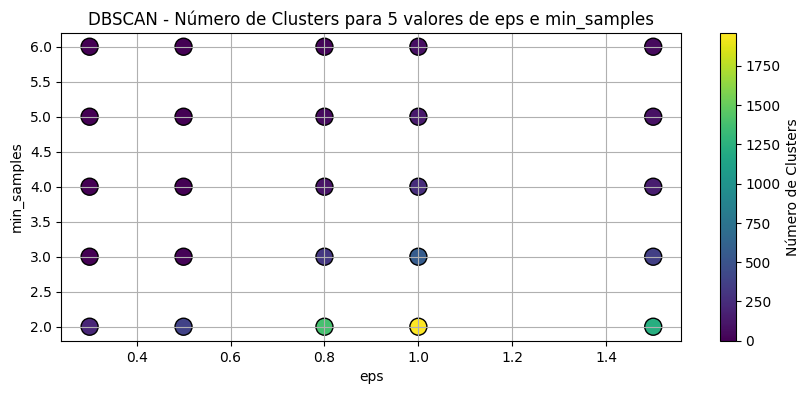

In [35]:
plt.figure(figsize=(10, 4))
scatter = plt.scatter(
    df_results["eps"],
    df_results["min_samples"],
    c=df_results["n_clusters"],
    cmap="viridis",
    s=150,
    edgecolor="black",
)
plt.colorbar(scatter, label="Número de Clusters")
plt.xlabel("eps")
plt.ylabel("min_samples")
plt.title("DBSCAN - Número de Clusters para 5 valores de eps e min_samples")
plt.grid(True)
plt.show()

In [36]:
dbscan = DBSCAN(eps=0.8, min_samples=3).fit(X_scaled)
labels = dbscan.labels_
X_filtered = X_scaled[labels != -1]
labels_filtered = labels[labels != -1]

In [37]:
perplexity = min(40, X_filtered.shape[0] - 1)
dbscan_tsne_coords = compute_tsne_2d(X_filtered, perplexity=perplexity, random_state=RANDOM_STATE)

In [38]:
dbscan_pca_coords = compute_pca_2d(X_filtered, random_state=RANDOM_STATE)

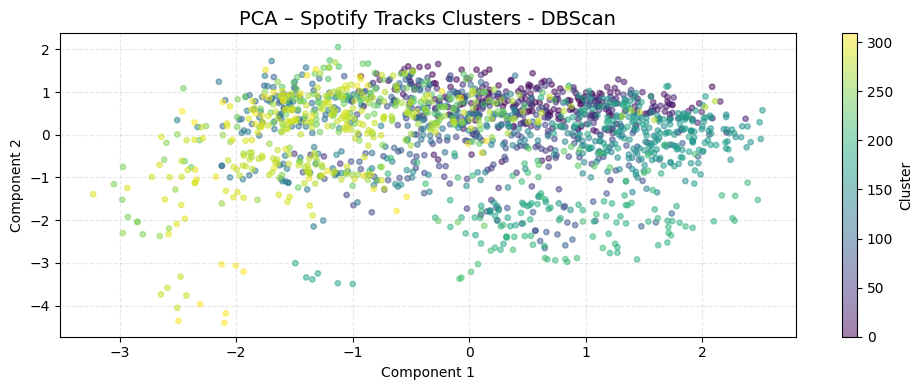

In [39]:
plot_embedding_2d(
    dbscan_pca_coords,
    labels_filtered,
    title="PCA – Spotify Tracks Clusters - DBScan",
)

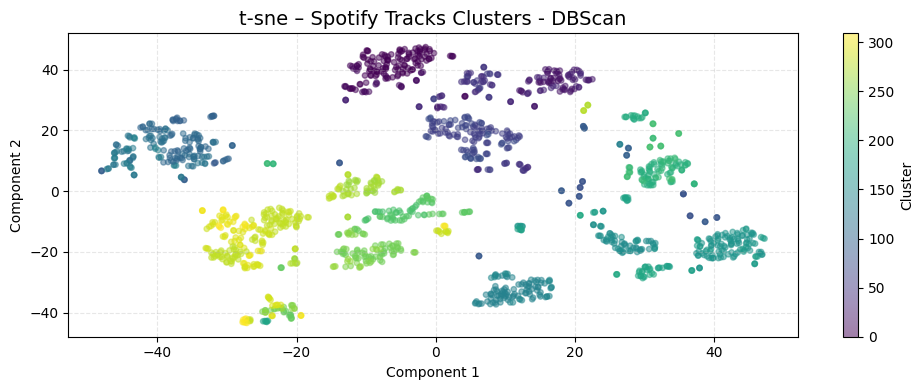

In [40]:
plot_embedding_2d(
    dbscan_tsne_coords,
    labels_filtered,
    title="t-sne – Spotify Tracks Clusters - DBScan",
)

## Hierarchical Clustering

### Looking for best k-value using 
### Hierarchical Clustering with Ward Linkage and Euclidean Distance

For our hierarchical clustering, we use the **Ward linkage method** combined with **Euclidean distance**. Here's why:

- **Ward linkage** minimizes the total within-cluster variance. At each step, it merges the pair of clusters that leads to the minimum increase in total within-cluster variance. This tends to create clusters that are compact and spherical, similar to k-means assumptions, and often produces more balanced clusters.
- **Euclidean distance** is the standard distance metric measuring the straight-line distance between points in the feature space. It works well with Ward linkage, as Ward's method relies on variance calculations based on Euclidean distances.

#### Finding the best number of clusters from the dendrogram

The dendrogram visually represents the hierarchical merging of samples/clusters. To choose the best number of clusters **k**:

- Look for the **largest vertical distance (gap)** between horizontal lines that do not cross any other horizontal lines (these represent cluster merges).
- Cutting the dendrogram at this large gap (horizontal line) will separate the data into clusters that are more dissimilar from each other, indicating better separation.
- In other words, the largest vertical jumps indicate natural cluster boundaries.

By selecting k corresponding to this largest vertical gap, we hope to identify the most meaningful cluster division of the data.

---

We will plot the dendrogram using this method and inspect it to decide the optimal k before quantitatively validating cluster quality with internal metrics like Silhouette score.


In [41]:
def plot_dendrogram(X, method="ward", metric="euclidean", truncate_mode=None, p=12):
    """
    Compute and plot the hierarchical clustering dendrogram.
    """
    Z = linkage(X, method=method, metric=metric)

    plt.figure(figsize=(15, 6))
    dendrogram(
        Z,
        truncate_mode=truncate_mode,
        p=p,
        leaf_rotation=90.0,
        leaf_font_size=10.0,
        show_contracted=True,
        color_threshold=None,
    )
    plt.title(f"Hierarchical Clustering Dendrogram ({method} linkage)")
    plt.xlabel("Sample index or cluster size")
    plt.ylabel("Distance")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return Z

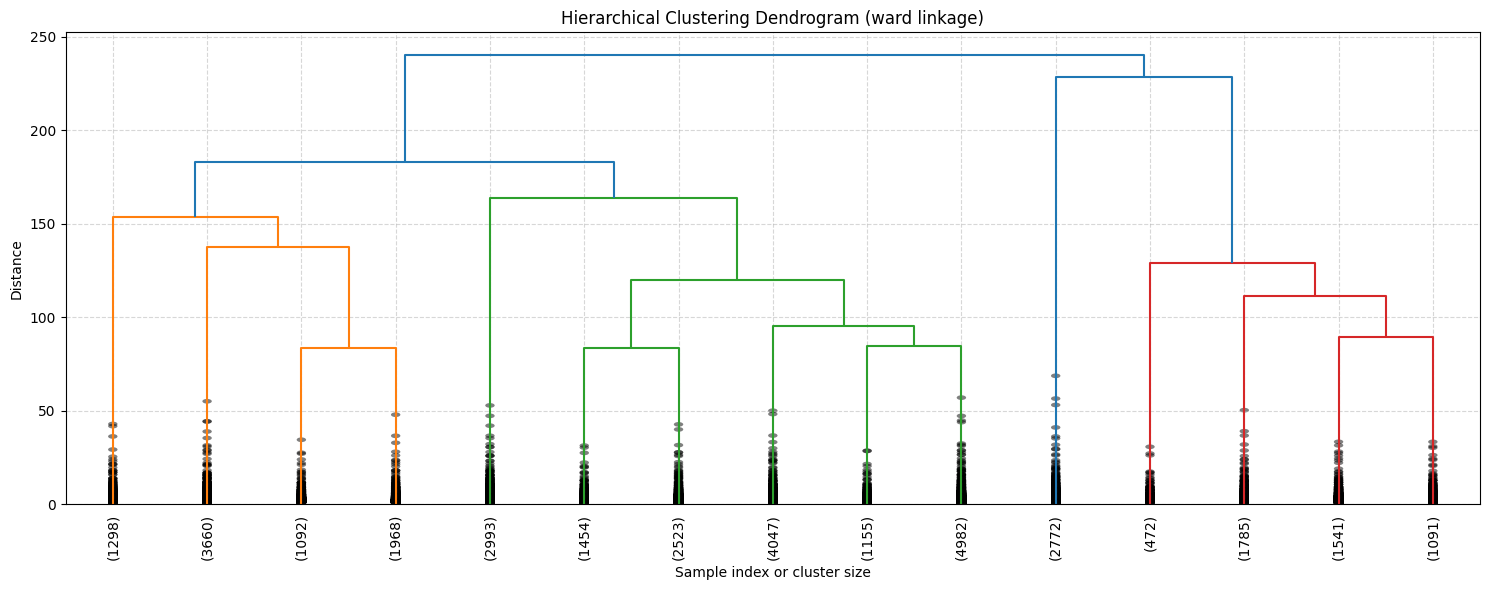

In [42]:
Z = plot_dendrogram(X_scaled, method="ward", truncate_mode="lastp", p=15)

The choice of \( K = 4 \) is based on cutting the dendrogram at a height of around 150, where four distinct clusters (blue, green, orange, red) emerge, maximizing inter-cluster distance and reflecting the data's natural structure.

In [43]:
N_CLUSTERS = 4

### Hierarchical Clustering Evaluation with Internal Validation Metrics

In [44]:
def get_hierarchical_labels(Z, n_clusters):
    """
    Extract flat cluster labels from linkage matrix by cutting the dendrogram.
    """

    labels = fcluster(Z, t=n_clusters, criterion="maxclust")
    return labels

In [45]:
hier_labels = get_hierarchical_labels(Z, n_clusters=N_CLUSTERS)

In [46]:
def evaluate_hierarchical_metrics(X, k_value, labels):
    """
    Calculate Silhouette, Davies-Bouldin, and Calinski-Harabasz scores for clustering labels.
    """
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    data = {
        "Silhouette": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch,
    }

    df = pd.DataFrame(data, index=[k_value]).T
    df.columns = [f"k={k_value}"]
    return df

In [47]:
hca_metrics_df = evaluate_hierarchical_metrics(
    X_scaled, k_value=N_CLUSTERS, labels=hier_labels
)
hca_metrics_df

,k=4
Silhouette,0.078535
Davies-Bouldin,2.879593
Calinski-Harabasz,2296.803941


### Visualizing Hierarchical Clustering in 2D (PCA and t-SNE)

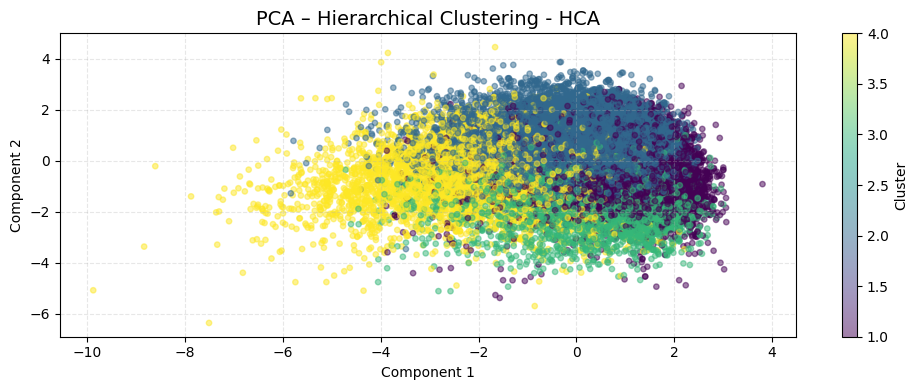

In [48]:
plot_embedding_2d(
    pca_coords,
    hier_labels,
    title="PCA – Hierarchical Clustering - HCA",
)

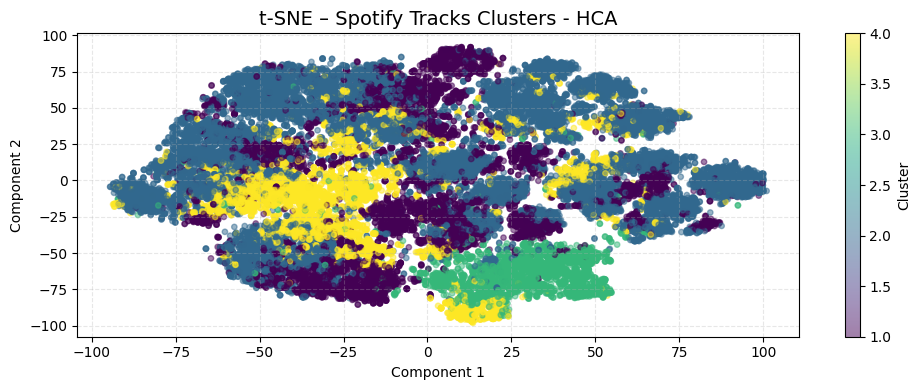

In [49]:
plot_embedding_2d(
    tsne_coords,
    hier_labels,
    title="t‑SNE – Spotify Tracks Clusters - HCA",
)